In [2]:
import numpy as np 
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM

In [3]:
# Set the maximum number of words (vocabulary size) to consider
max_features = 20000
# Set the maximum length of a review (sequences longer than this will be truncated, shorter padded)
maxlen = 100

print("Loading data...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
print(f"{len(x_train)} train sequences")
print(f"{len(x_test)} test sequences")

print("Pad sequences (samples x time)")
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

Loading data...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 65s 4us/step
25000 train sequences
25000 test sequences
Pad sequences (samples x time)
x_train shape: (25000, 100)
x_test shape: (25000, 100)


In [4]:
model = Sequential()

# 1. Embedding Layer: Turns word integers into dense vectors of fixed size (128 dimensions)
model.add(Embedding(input_dim=max_features, output_dim=128, input_length=maxlen))

# 2. LSTM Layer: Learns the sequential patterns in text (128 memory units)
# dropout and recurrent_dropout help prevent overfitting
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))

# 3. Output Layer: Single neuron with Sigmoid activation for binary classification (0 = negative, 1 = positive)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
batch_size = 32
epochs = 5

print('Training the model...')
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test))

Training the model...
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 125ms/step - accuracy: 0.7895 - loss: 0.4563 - val_accuracy: 0.8408 - val_loss: 0.3745
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.8769 - loss: 0.3016 - val_accuracy: 0.8373 - val_loss: 0.3799
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 122ms/step - accuracy: 0.9174 - loss: 0.2146 - val_accuracy: 0.8296 - val_loss: 0.3857
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 128ms/step - accuracy: 0.9450 - loss: 0.1508 - val_accuracy: 0.8394 - val_loss: 0.4720
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 128ms/step - accuracy: 0.9621 - loss: 0.1043 - val_accuracy: 0.8349 - val_loss: 0.5096


In [6]:
score, acc = model.evaluate(x_test, y_test, batch_size=batch_size)
print(f'Test loss: {score:.4f}')
print(f'Test accuracy: {acc:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8349 - loss: 0.5096
Test loss: 0.5096
Test accuracy: 0.8349


In [7]:
# 1. Get the word index map from the IMDB dataset
word_index = imdb.get_word_index()

def predict_sentiment(review_text):
    # Clean and tokenize the input text
    words = review_text.lower().split()
    
    # Convert words to their corresponding integer indices
    # IMDB indices are offset by 3 because 0, 1, and 2 are reserved for padding, start, and unknown words
    review_seq = [word_index.get(word, 0) + 3 for word in words]
    
    # Filter out words that exceed our max vocabulary size
    review_seq = [idx if idx < max_features else 2 for idx in review_seq]
    
    # Pad the sequence to match the input shape (maxlen = 100)
    padded_seq = sequence.pad_sequences([review_seq], maxlen=maxlen)
    
    # Make the prediction
    prediction = model.predict(padded_seq)[0][0]
    
    # Interpret the output
    sentiment = "Positive" if prediction >= 0.5 else "Negative"
    print(f"\nReview: \"{review_text}\"")
    print(f"Predicted Sentiment: {sentiment} (Confidence Score: {prediction:.4f})")

# --- Test it out! ---

# Test a positive review
predict_sentiment("This movie was absolutely amazing The acting was brilliant and the plot was gripping")

# Test a negative review
predict_sentiment("What a waste of time The plot made no sense and the acting was terrible")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 14s 9us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step

Review: "This movie was absolutely amazing The acting was brilliant and the plot was gripping"
Predicted Sentiment: Positive (Confidence Score: 0.9819)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Review: "What a waste of time The plot made no sense and the acting was terrible"
Predicted Sentiment: Negative (Confidence Score: 0.0002)


In [8]:
# Save the entire model to a file
model.save('sentiment_lstm_model.keras')
print("Model saved successfully!")

Model saved successfully!


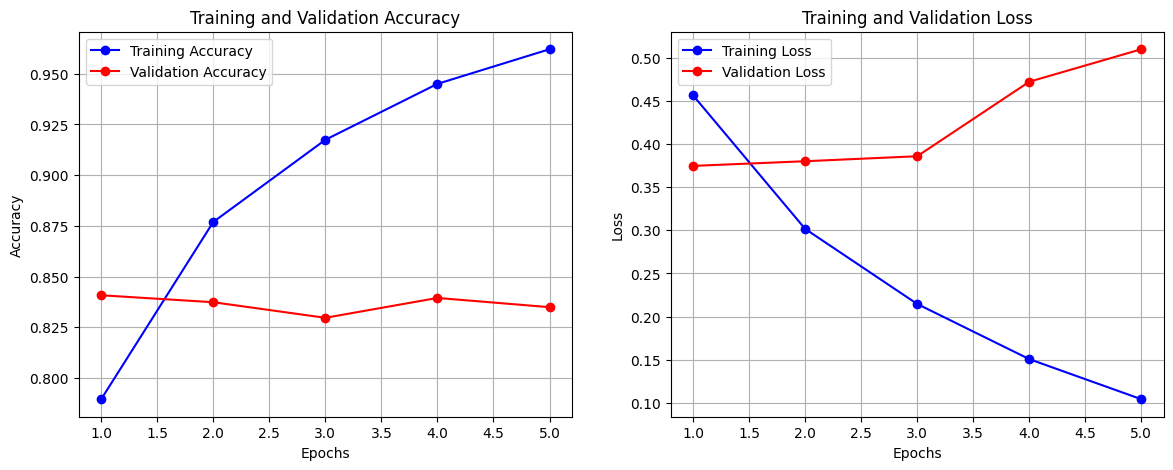

In [9]:
import matplotlib.pyplot as plt

# Retrieve training results from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Create a figure for the plots
plt.figure(figsize=(14, 5))

# Plot 1: Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot 2: Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'bo-', label='Training Loss')
plt.plot(epochs_range, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

Generating predictions for the test set...
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step

=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.86      0.80      0.83     12500
    Positive       0.81      0.87      0.84     12500

    accuracy                           0.83     25000
   macro avg       0.84      0.83      0.83     25000
weighted avg       0.84      0.83      0.83     25000



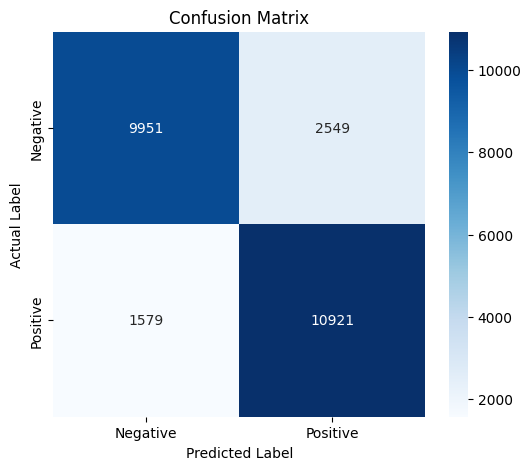

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. Generate predictions on the test dataset
print("Generating predictions for the test set...")
raw_predictions = model.predict(x_test, batch_size=32)

# Convert probabilities (0.0 to 1.0) into binary classes (0 or 1)
y_pred = (raw_predictions >= 0.5).astype("int32")

# 2. Print the Classification Report (Precision, Recall, F1-Score)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# 3. Compute and Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [11]:
import json

# 1. Save the trained Keras model structure and weights
model_version = "v1"
model_filename = f"sentiment_lstm_model_{model_version}.keras"
model.save(model_filename)
print(f"✓ Model successfully saved to disk as: '{model_filename}'")

# 2. Save the IMDB word index map as a JSON file
# This is crucial so you can preprocess text exactly the same way in the future
config_filename = "imdb_word_index.json"
with open(config_filename, 'w') as f:
    json.dump(word_index, f)
print(f"✓ Word index configuration successfully saved as: '{config_filename}'")

✓ Model successfully saved to disk as: 'sentiment_lstm_model_v1.keras'
✓ Word index configuration successfully saved as: 'imdb_word_index.json'


In [12]:
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import sequence

print("Simulating production server startup...")

# 1. Load the saved model weights and architecture
loaded_model = tf.keras.models.load_model('sentiment_lstm_model_v1.keras')
print("✓ Model loaded into memory successfully.")

# 2. Load the word index dictionary
with open('imdb_word_index.json', 'r') as f:
    loaded_word_index = json.load(f)
print("✓ Vocabulary index mapped successfully.")

# 3. Production Inference Function
def production_inference(raw_input_text, maxlen=100, max_features=20000):
    # Clean text and split into tokens
    words = raw_input_text.lower().split()
    
    # Map words to indices based on loaded json configuration
    # (Using the same +3 offset required by the IMDB source dataset layout)
    seq = [loaded_word_index.get(word, 0) + 3 for word in words]
    seq = [idx if idx < max_features else 2 for idx in seq]
    
    # Pad sequence to match model input structure
    padded = sequence.pad_sequences([seq], maxlen=maxlen)
    
    # Predict probability score
    raw_score = loaded_model.predict(padded, verbose=0)[0][0]
    
    # Determine sentiment class flag
    label = "POSITIVE 😄" if raw_score >= 0.5 else "NEGATIVE 😞"
    
    print("-" * 50)
    print(f"Incoming Text : {raw_input_text}")
    print(f"Analysis Result: {label} (Confidence: {raw_score * 100:.2f}%)")

# --- Test Live Server Deployment ---
print("\n--- Live API Gateway Testing ---")
production_inference("The cinematography was beautiful but the pacing was incredibly slow and boring")
production_inference("This is hands down the best film of the entire year masterpiece performance")

Simulating production server startup...
✓ Model loaded into memory successfully.
✓ Vocabulary index mapped successfully.

--- Live API Gateway Testing ---
--------------------------------------------------
Incoming Text : The cinematography was beautiful but the pacing was incredibly slow and boring
Analysis Result: NEGATIVE 😞 (Confidence: 25.34%)
--------------------------------------------------
Incoming Text : This is hands down the best film of the entire year masterpiece performance
Analysis Result: POSITIVE 😄 (Confidence: 98.38%)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Bidirectional

# 1. Completely re-initialize the model container
model = Sequential()

# 2. Add the Input/Embedding layer
model.add(Embedding(input_dim=max_features, output_dim=128, input_length=maxlen))

# 3. Add the upgraded Bidirectional LSTM layer
model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)))

# 4. Add the dense output layer
model.add(Dense(1, activation='sigmoid'))

# 5. Re-compile the fresh model architecture
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
batch_size = 32
epochs = 5

print('Training the upgraded Bidirectional LSTM model...')
# We feed it the same x_train and y_train data from Step 1
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test))

Training the upgraded Bidirectional LSTM model...
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 227s 282ms/step - accuracy: 0.7897 - loss: 0.4512 - val_accuracy: 0.8454 - val_loss: 0.3560
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 215s 275ms/step - accuracy: 0.8913 - loss: 0.2704 - val_accuracy: 0.8378 - val_loss: 0.3754
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 213s 272ms/step - accuracy: 0.9348 - loss: 0.1750 - val_accuracy: 0.8374 - val_loss: 0.3942
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 212s 271ms/step - accuracy: 0.9614 - loss: 0.1084 - val_accuracy: 0.8296 - val_loss: 0.4778
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 211s 270ms/step - accuracy: 0.9770 - loss: 0.0672 - val_accuracy: 0.8315 - val_loss: 0.5795


In [16]:
# Evaluate the new model on the test data
bi_score, bi_acc = model.evaluate(x_test, y_test, batch_size=batch_size)

print("\n=== Upgraded Model Evaluation ===")
print(f'Bidirectional Test Loss: {bi_score:.4f}')
print(f'Bidirectional Test Accuracy: {bi_acc:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.8315 - loss: 0.5795

=== Upgraded Model Evaluation ===
Bidirectional Test Loss: 0.5795
Bidirectional Test Accuracy: 0.8315


In [17]:
# Save this upgraded model under a unique name
bi_model_filename = "sentiment_bidirectional_lstm_model.keras"
model.save(bi_model_filename)

print(f"✓ Upgraded Bidirectional model successfully saved as: '{bi_model_filename}'")

✓ Upgraded Bidirectional model successfully saved as: 'sentiment_bidirectional_lstm_model.keras'


In [18]:
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import sequence

# 1. Load the shared word index
with open('imdb_word_index.json', 'r') as f:
    word_index = json.load(f)

# 2. Load both models from disk
print("Loading models for comparison...")
model_baseline = tf.keras.models.load_model('sentiment_lstm_model_v1.keras')
model_bidirectional = tf.keras.models.load_model('sentiment_bidirectional_lstm_model.keras')
print("✓ Both models loaded successfully.\n")

def compare_models(review_text, maxlen=100, max_features=20000):
    # Preprocess the input text
    words = review_text.lower().split()
    seq = [word_index.get(word, 0) + 3 for word in words]
    seq = [idx if idx < max_features else 2 for idx in seq]
    padded = sequence.pad_sequences([seq], maxlen=maxlen)
    
    # Get predictions from both models
    pred_base = model_baseline.predict(padded, verbose=0)[0][0]
    pred_bi = model_bidirectional.predict(padded, verbose=0)[0][0]
    
    # Determine labels
    label_base = "POSITIVE 😄" if pred_base >= 0.5 else "NEGATIVE 😞"
    label_bi = "POSITIVE 😄" if pred_bi >= 0.5 else "NEGATIVE 😞"
    
    # Print a clean comparison card
    print("=" * 60)
    print(f"Review text: \"{review_text}\"")
    print("-" * 60)
    print(f"Standard LSTM   : {label_base} (Confidence: {pred_base*100:.2f}%)")
    print(f"Bidirectional   : {label_bi} (Confidence: {pred_bi*100:.2f}%)")
    print("=" * 60 + "\n")

# --- Run the Comparison Matrix ---
# Test Case 1: Sarcasm/Nuance (Where Bidirectional often shines)
compare_models("Definitively not your typical masterpiece but it kept me entertained throughout")

# Test Case 2: Highly Negative
compare_models("The acting was terrible and the editing made it completely unwatchable")

Loading models for comparison...
✓ Both models loaded successfully.

Review text: "Definitively not your typical masterpiece but it kept me entertained throughout"
------------------------------------------------------------
Standard LSTM   : POSITIVE 😄 (Confidence: 98.06%)
Bidirectional   : POSITIVE 😄 (Confidence: 96.58%)

Review text: "The acting was terrible and the editing made it completely unwatchable"
------------------------------------------------------------
Standard LSTM   : NEGATIVE 😞 (Confidence: 0.04%)
Bidirectional   : NEGATIVE 😞 (Confidence: 0.00%)

